In [1]:
import os
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Setup directory paths (using current working directory for Jupyter)
notebook_dir = os.getcwd()
root_dir=os.path.dirname(os.path.dirname(notebook_dir))

output_dir = os.path.join(root_dir, "output", "sh-03")
file_path = os.path.join(root_dir, "raw_data", "SH-03 COBBLE 23112024.parquet")

print(f"Target file path: {file_path}")
print(f"Output directory: {output_dir}")

Target file path: c:\Users\Aditya Singh\Desktop\INTERN\raw_data\SH-03 COBBLE 23112024.parquet
Output directory: c:\Users\Aditya Singh\Desktop\INTERN\output\sh-03


In [2]:
print(f"Reading and downsampling data from {file_path}")
print("Processing in chunks with vectorized downsampling...")

parquet_file = pq.ParquetFile(file_path)
downsampled_chunks = []
global_row_count = 0

# Process in batches of 10,000 rows
for batch in parquet_file.iter_batches(batch_size=10000):
    df_chunk = batch.to_pandas()
    chunk_len = len(df_chunk)
    
    # Calculate the exact starting index for this chunk to maintain the global "every 100th row" rule
    remainder = global_row_count % 100
    start_idx = 0 if remainder == 0 else (100 - remainder)
    
    if start_idx < chunk_len:
        # Slicing with [start::100] is fully vectorized and incredibly fast
        downsampled_chunks.append(df_chunk.iloc[start_idx::100].copy())
        
    global_row_count += chunk_len
    print(f"Processed {global_row_count} rows...", end='\r')
    
print(f"\nFinished reading. Concatenating chunks...")
df_down = pd.concat(downsampled_chunks, ignore_index=True)
print(f"Downsampled dataframe shape: {df_down.shape}")

# Ensure Timestamp is handled correctly
if 'Timestamp' in df_down.columns:
    df_down['Timestamp'] = pd.to_datetime(df_down['Timestamp'])
    print("Timestamp column successfully converted to datetime.")

Reading and downsampling data from c:\Users\Aditya Singh\Desktop\INTERN\raw_data\SH-03 COBBLE 23112024.parquet
Processing in chunks with vectorized downsampling...
Processed 420000 rows...
Finished reading. Concatenating chunks...
Downsampled dataframe shape: (4200, 10646)
Timestamp column successfully converted to datetime.


In [3]:
print("Pre-calculating standard deviations for all columns...")
# Convert bools to float for unified std calculation; non-numeric columns will be ignored here
numeric_bool_df = df_down.select_dtypes(include=[np.number, 'bool'])
stds = numeric_bool_df.astype(float).std().fillna(0)
print("Standard deviations calculated successfully.")

Pre-calculating standard deviations for all columns...
Standard deviations calculated successfully.


In [4]:
# ================================================================
# COBBLE DETECTION ANALYSIS
# ================================================================
print("\n" + "=" * 70)
print("COBBLE DETECTION ANALYSIS")
print("=" * 70)

# The 24 cobble detection columns (one per stand)
cobble_cols = [
    f'[13_{87 + i}]STD{str(i + 1).zfill(2)} COBBLE DETECTED (TRACKING)'
    for i in range(24)
]

# Check which cobble columns exist in the downsampled data
cobble_present = [c for c in cobble_cols if c in df_down.columns]
cobble_missing = [c for c in cobble_cols if c not in df_down.columns]

print(f"\nCobble columns found: {len(cobble_present)} / 24")
if cobble_missing:
    print(f"Cobble columns missing: {len(cobble_missing)}")

# Check each stand for cobble events
total_cobble_rows = 0
stands_with_cobble = []

print(f"\n{'Stand':<10} {'Cobble Rows':<15} {'% of Data':<12} {'First Row':<12} {'Last Row':<12}")
print("-" * 61)

for col in cobble_present:
    # Extract stand name
    stand = col.split(']')[1].split(' ')[0]  # e.g., "STD05"

    # Count rows where cobble = True
    cobble_mask = df_down[col].astype(bool)
    n_cobble = cobble_mask.sum()

    if n_cobble > 0:
        first_row = cobble_mask.idxmax()
        last_row = len(cobble_mask) - 1 - cobble_mask[::-1].idxmax()
        pct = 100 * n_cobble / len(df_down)
        print(f"{stand:<10} {n_cobble:<15} {pct:<12.2f} {first_row:<12} {last_row:<12}")
        stands_with_cobble.append(stand)
        total_cobble_rows = max(total_cobble_rows, n_cobble)
    else:
        pass  # Skip stands with no cobble (keeps output clean)

# Overall summary
any_cobble = df_down[cobble_present].astype(bool).any(axis=1)
total_any = any_cobble.sum()

print("-" * 61)
print(f"\nSUMMARY:")
print(f"  Total rows in downsampled data:    {len(df_down):,}")
print(f"  Rows with cobble (any stand):      {total_any:,}")
print(f"  Rows without cobble:               {len(df_down) - total_any:,}")
print(f"  Cobble percentage:                 {100 * total_any / len(df_down):.2f}%")
print(f"  Stands affected by cobble:         {len(stands_with_cobble)}")
if stands_with_cobble:
    print(f"  Affected stands:                   {', '.join(stands_with_cobble)}")

# Find cobble onset (first row where ANY stand detects cobble)
if total_any > 0:
    onset_idx = any_cobble.idxmax()
    # If we have timestamps
    if 'Timestamp' in df_down.columns:
        onset_time = df_down.loc[onset_idx, 'Timestamp']
        print(f"  Cobble onset (downsampled row):    {onset_idx}")
        print(f"  Cobble onset (timestamp):          {onset_time}")
    else:
        print(f"  Cobble onset (downsampled row):    {onset_idx}")

    # Count distinct cobble "events" (separated by gaps of >10 rows of no-cobble)
    cobble_indices = any_cobble[any_cobble].index.to_numpy()
    gaps = np.diff(cobble_indices)
    n_events = 1 + (gaps > 10).sum()  # new event if gap > 10 seconds
    print(f"\n  Number of distinct cobble events:  {n_events}")
    print(f"  (Events separated by gaps of >10 seconds of no-cobble)")
else:
    print(f"\n  *** NO COBBLE EVENTS DETECTED IN THIS DATASET ***")

print("=" * 70)


COBBLE DETECTION ANALYSIS

Cobble columns found: 24 / 24

Stand      Cobble Rows     % of Data    First Row    Last Row    
-------------------------------------------------------------
STD05      21              0.50         2263         1916        
STD06      21              0.50         2263         1916        
STD07      21              0.50         2263         1916        
STD08      21              0.50         2263         1916        
STD09      21              0.50         2263         1916        
STD10      21              0.50         2263         1916        
STD11      21              0.50         2263         1916        
STD12      23              0.55         897          1916        
STD13      23              0.55         897          1916        
STD14      23              0.55         897          1916        
STD15      23              0.55         897          1916        
STD16      23              0.55         897          1916        
STD17      2         

In [5]:
print("Identifying column types (Boolean, Constant, Analog)...")
constant_cols = []
bool_cols = []
analog_cols = []

# Process numeric/boolean columns based on pre-calculated stds
for col in df_down.columns:
    if col in stds.index:
        col_std = stds[col]
        if col_std == 0:
            constant_cols.append(col)
        elif pd.api.types.is_bool_dtype(df_down[col]):
            bool_cols.append(col)
        else:
            # Fast check for 0/1 columns using downsampled data
            unique_vals = set(df_down[col].dropna().unique())
            if unique_vals.issubset({0, 1, 0.0, 1.0}):
                bool_cols.append(col)
            else:
                analog_cols.append(col)
    else:
        # Handle non-numeric columns (e.g., strings/objects)
        if df_down[col].nunique(dropna=False) <= 1:
            constant_cols.append(col)
        else:
            analog_cols.append(col)

print(f"Found {len(bool_cols)} boolean, {len(constant_cols)} constant, and {len(analog_cols)} analog columns.")

Identifying column types (Boolean, Constant, Analog)...
Found 1511 boolean, 7719 constant, and 1416 analog columns.


In [6]:
def sort_cols_by_std(cols):
    col_stds = {c: stds[c] if c in stds.index else 0 for c in cols}
    return sorted(col_stds, key=col_stds.get, reverse=True)

print("Sorting columns by standard deviation (high fluctuation to low)...")
sorted_bool = sort_cols_by_std(bool_cols)
sorted_analog = sort_cols_by_std(analog_cols)
sorted_const = sort_cols_by_std(constant_cols)

print("Saving categorized datasets to CSV...")
# Updated saving paths to output_dir
df_down[sorted_bool].to_csv(os.path.join(output_dir, "boolean_columns.csv"), index=False)
df_down[sorted_analog].to_csv(os.path.join(output_dir, "analog_columns.csv"), index=False)
df_down[sorted_const].to_csv(os.path.join(output_dir, "constant_columns.csv"), index=False)
print(f"Categorized CSVs saved successfully to {output_dir}")

Sorting columns by standard deviation (high fluctuation to low)...
Saving categorized datasets to CSV...
Categorized CSVs saved successfully to c:\Users\Aditya Singh\Desktop\INTERN\output\sh-03


In [7]:
print("Extracting specific parameters (Speed, Torque, Current, Power, Looper, Vibration)...")
param_keywords = {
    'speed': ['speed'],
    'torque': ['torque'],
    'current': ['current'],
    'power': ['power'],
    'looper': ['loop', 'l1112', 'l1213', 'l1314', 'l1415', 'l1516', 'l1617', 'l1718', 'l1819', 'l1920', 'l2021', 'l24fb'],
    'vibration': ['vib'] # Updated keyword from 'vibr' to 'vib'
}

params_cols = {k: [] for k in param_keywords.keys()}
all_cols_lower = {str(col).lower(): col for col in df_down.columns}

# Vector-like matching using dictionary lookups
for col_lower, original_col in all_cols_lower.items():
    for param, keywords in param_keywords.items():
        if any(kw in col_lower for kw in keywords):
            params_cols[param].append(original_col)

all_param_cols = list(set().union(*params_cols.values()))

# Add Timestamp to the front of all_parameters if it exists
if 'Timestamp' in df_down.columns and 'Timestamp' not in all_param_cols:
    all_param_cols.insert(0, 'Timestamp')

print(f"Found {len(all_param_cols)} columns across all specified parameters.")
df_down[all_param_cols].to_csv(os.path.join(output_dir, "all_parameters.csv"), index=False)

Extracting specific parameters (Speed, Torque, Current, Power, Looper, Vibration)...
Found 967 columns across all specified parameters.


In [8]:
print("Finding highest standard deviation column for each parameter...")
highest_cols = []
for param, cols in params_cols.items():
    if not cols:
        print(f"  {param}: No columns found.")
        continue
    
    param_stds = {c: stds[c] if c in stds.index else 0 for c in cols}
    highest_col = max(param_stds, key=param_stds.get)
    highest_val = param_stds[highest_col]
    
    print(f"  {param}: {highest_col} (std = {highest_val:.4f})")
    highest_cols.append(highest_col)

# Ensure Timestamp accompanies highest columns output
output_cols = list(highest_cols)
if 'Timestamp' in df_down.columns:
    output_cols.insert(0, 'Timestamp')

print("\nSaving highest fluctuation dataset...")
df_down[output_cols].to_csv(os.path.join(output_dir, "highest_std_parameters.csv"), index=False)

Finding highest standard deviation column for each parameter...
  speed: [14:24]Drive Fbk Speed INSRT_S1 (std = 5021.7902)
  torque: [6:46]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_TORQUE (std = 456.9820)
  current: [19:37]SH003: Drive - Actual Current (std = 1328.1441)
  power: [7:19]CZ75 COA Fan 01 Drv Power Count Val (std = 747.1153)
  looper: [17:31]Loop Height ANALOGUE L24FB (std = 5005.3533)
  vibration: [12:108]CZ75_SNS_VT75_11_CA_FAN1_VIB (std = 263.6191)

Saving highest fluctuation dataset...


In [9]:
def normalize_series(series):
    """Scales a pandas Series strictly between 0 and 1."""
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return series * 0.0  # Avoid division by zero if the column is constant
    return (series - min_val) / (max_val - min_val)

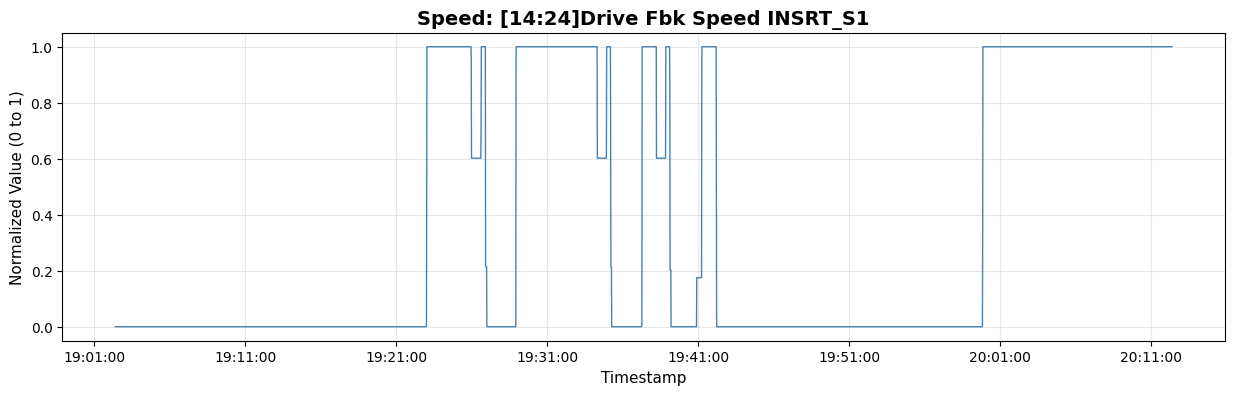

In [10]:
param = 'speed'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)

    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='steelblue')
    plt.title(f"Speed: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

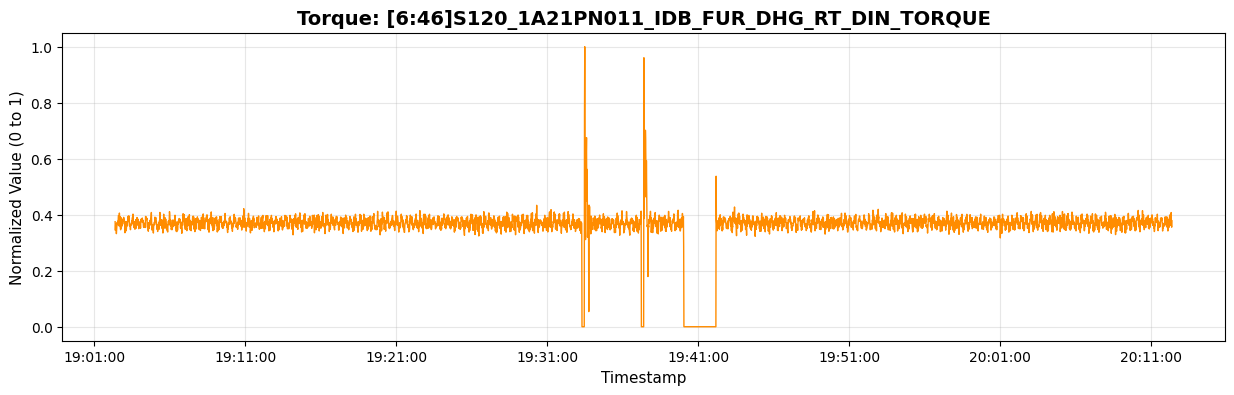

In [11]:
param = 'torque'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='darkorange')
    plt.title(f"Torque: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

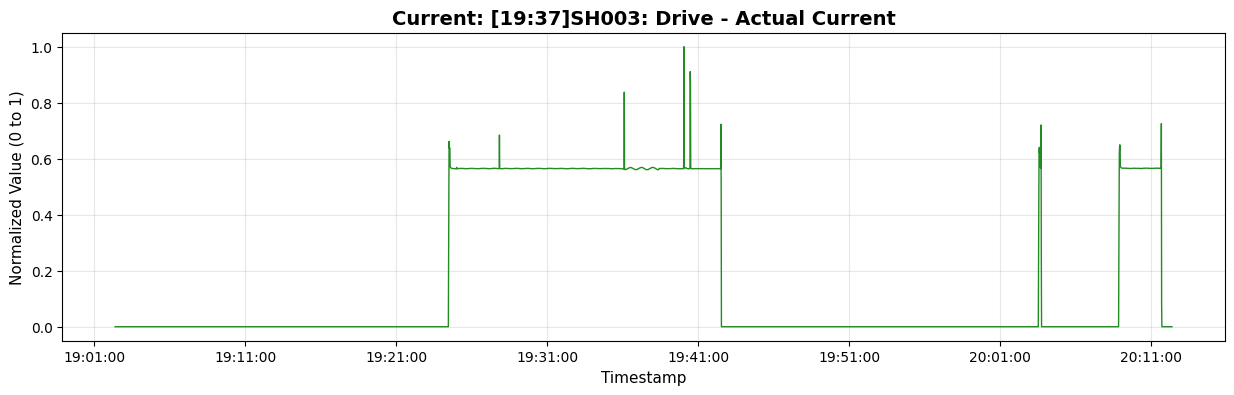

In [12]:
param = 'current'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='forestgreen')
    plt.title(f"Current: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

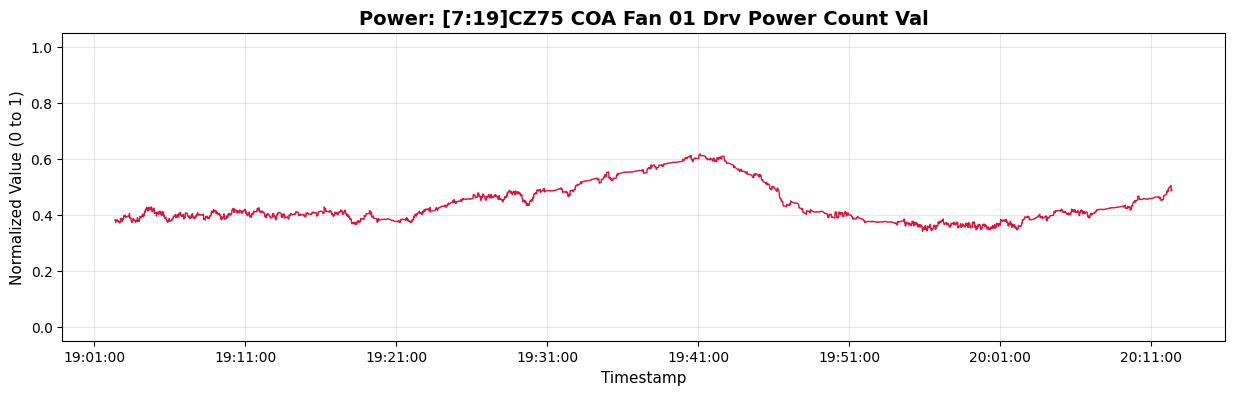

In [13]:
param = 'power'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)

    
    norm_series = normalize_series(df_down[col])
    smoothed_series = norm_series.rolling(window=30, min_periods=1, center=True).mean()
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], smoothed_series, linewidth=1, color='crimson')
    plt.title(f"Power: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

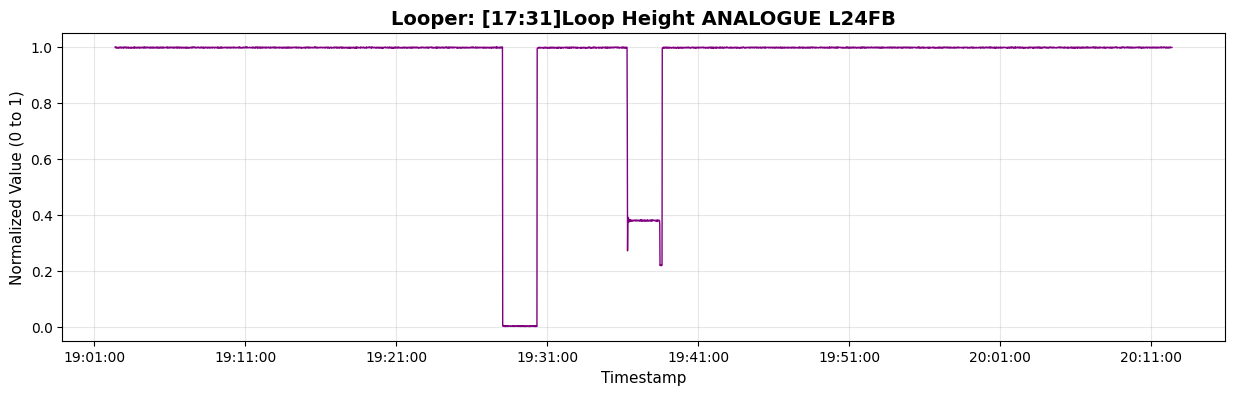

In [14]:
param = 'looper'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], normalize_series(df_down[col]), linewidth=1, color='purple')
    plt.title(f"Looper: {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_plot.png"), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"No data found for {param}")

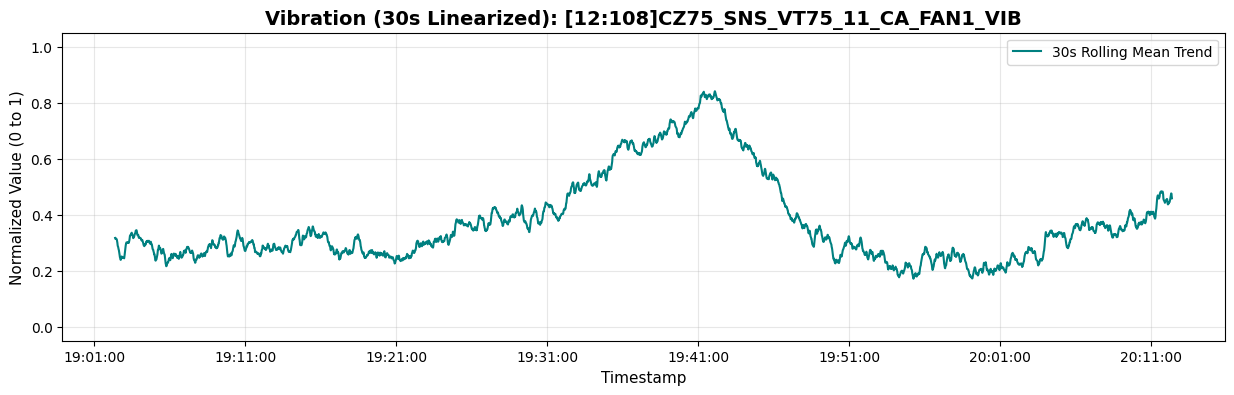

In [15]:
param = 'vibration'
if params_cols[param] and 'Timestamp' in df_down.columns:
    # Change this pattern in ALL your plot cells:
    param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
    col = max(param_stds, key=param_stds.get)
    
    # 1. Normalize original series
    norm_series = normalize_series(df_down[col])
    
    # 2. Linearize/smooth trends over a 30-second rolling window
    smoothed_series = norm_series.rolling(window=30, min_periods=1, center=True).mean()
    
    plt.figure(figsize=(15, 4))
    plt.plot(df_down['Timestamp'], smoothed_series, linewidth=1.5, color='teal', label='30s Rolling Mean Trend')
    plt.title(f"Vibration (30s Linearized): {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Normalized Value (0 to 1)", fontsize=11)
    plt.xlabel("Timestamp", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.savefig(os.path.join(output_dir, f"{param}_normalized_trend_plot.png"), dpi=150, bbox_inches='tight')
    plt.legend()
    plt.show()
else:
    print(f"No data found for {param}")

In [16]:
param = 'speed'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: SPEED ===
01. Std Dev: 5021.7902 -> [14:24]Drive Fbk Speed INSRT_S1
02. Std Dev: 5021.7902 -> [14:25]Drive Fbk Speed INSRT_S2
03. Std Dev: 5021.3551 -> [14:217]Drive Speed Reference INSRT_S2
04. Std Dev: 4936.9310 -> [14:216]Drive Speed Reference INSRT_S1
05. Std Dev: 4855.7640 -> [14:212]Drive Speed Reference EXFRT_S1
06. Std Dev: 4854.1623 -> [14:20]Drive Fbk Speed EXFRT_S1
07. Std Dev: 4814.1451 -> [14:21]Drive Fbk Speed EXFRT_S2
08. Std Dev: 4795.0688 -> [14:23]Drive Fbk Speed PR002
09. Std Dev: 4790.2562 -> [14:213]Drive Speed Reference EXFRT_S2
10. Std Dev: 3866.7967 -> [19:56]PR003: Drive - Reference Speed
11. Std Dev: 3866.5222 -> [19:32]PR003: Drive - Actual Speed
12. Std Dev: 3836.3834 -> [14:215]Drive Speed Reference PR002
13. Std Dev: 2346.0956 -> [14:22]Drive Fbk Speed PR001
14. Std Dev: 2145.3030 -> [19:59]SH003: Drive - Reference Speed
15. Std Dev: 2143.6173 -> [19:36]SH003: Drive - Actual Speed
16. Std Dev: 1569.1719 -> [14:214]D

In [17]:
param = 'torque'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: TORQUE ===
01. Std Dev: 456.9820 -> [6:46]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_TORQUE
02. Std Dev: 333.5212 -> [6:58]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_TORQUE
03. Std Dev: 307.0213 -> [6:40]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_TORQUE
04. Std Dev: 248.4062 -> [6:66]S120_1A21PN005_IDB_KICK_IN_ARM_03_DIN_TORQUE
05. Std Dev: 231.0869 -> [6:72]S120_1A21PN006_IDB_KICK_IN_ARM_04_DIN_TORQUE
06. Std Dev: 227.5545 -> [19:57]PR003: Drive - Reference Torque Positive
07. Std Dev: 227.5545 -> [19:58]PR003: Drive - Reference Torque Negative
08. Std Dev: 226.7004 -> [6:52]S120_1A21PN003_IDB_KICK_IN_ARM_01_DIN_TORQUE
09. Std Dev: 206.4321 -> [6:34]FERT_SEC1_DRV_IDB_DIN_TORQUE
10. Std Dev: 160.9943 -> [19:38]SH003: Drive - Actual Torque
11. Std Dev: 16.6308 -> [13:5]STD06 - T FBK Torque Norm
12. Std Dev: 16.4982 -> [13:10]STD11 - T FBK Torque Norm
13. Std Dev: 16.4775 -> [13:15]STD16 - T FBK Torque Norm
14. Std Dev: 16.2757 -> [13:13]STD14 - T FBK Torque Norm
15. S

In [18]:
param = 'current'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: CURRENT ===
01. Std Dev: 1328.1441 -> [19:37]SH003: Drive - Actual Current
02. Std Dev: 1071.6658 -> [6:45]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_CURRENT
03. Std Dev: 833.6631 -> [6:97]S120_1A21PN010_IDB_KICK_OFF_4_DIN_CURRENT
04. Std Dev: 611.9511 -> [6:39]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_CURRENT
05. Std Dev: 590.5582 -> [6:65]S120_1A21PN005_IDB_KICK_IN_ARM_03_DIN_CURRENT
06. Std Dev: 584.2474 -> [6:33]FERT_SEC1_DRV_IDB_DIN_CURRENT
07. Std Dev: 563.3284 -> [6:51]S120_1A21PN003_IDB_KICK_IN_ARM_01_DIN_CURRENT
08. Std Dev: 544.8090 -> [6:57]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_CURRENT
09. Std Dev: 541.6802 -> [6:71]S120_1A21PN006_IDB_KICK_IN_ARM_04_DIN_CURRENT
10. Std Dev: 265.3050 -> [7:17]CZ75 COA Fan 01 Drv Current Count Val
11. Std Dev: 160.8733 -> [2:305]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP3_LINE_CURRENT
12. Std Dev: 156.3959 -> [2:309]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP3_LINE_CURRENT
13. Std Dev: 144.2725 -> [2:240]PLC01_HMI_STATUS_

In [19]:
param = 'power'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: POWER ===
01. Std Dev: 747.1153 -> [7:19]CZ75 COA Fan 01 Drv Power Count Val
02. Std Dev: 255.1113 -> [2:304]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP3_POWER
03. Std Dev: 236.4657 -> [2:308]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP3_POWER
04. Std Dev: 218.6988 -> [2:296]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP2_POWER
05. Std Dev: 211.3407 -> [2:300]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP2_POWER
06. Std Dev: 205.0245 -> [2:288]PLC01_HMI_STATUS_DCBUS_STATUS_SLM1_LINEUP1_POWER
07. Std Dev: 202.6342 -> [6:47]S120_1A21PN011_IDB_FUR_DHG_RT_DIN_POWER
08. Std Dev: 190.4746 -> [2:292]PLC01_HMI_STATUS_DCBUS_STATUS_SLM3_LINEUP1_POWER
09. Std Dev: 174.1819 -> [6:59]S120_1A21PN004_IDB_KICK_IN_ARM_02_DIN_POWER
10. Std Dev: 172.0111 -> [2:246]PLC01_HMI_STATUS_ENERGY_METER_EM_1A01PN005_APPARENT_POWER
11. Std Dev: 161.0127 -> [6:35]FERT_SEC1_DRV_IDB_DIN_POWER
12. Std Dev: 157.2663 -> [6:41]S120_1A21PN002_IDB_FUR_CHRG_RT_DIN_POWER
13. Std Dev: 135.0262 -> [6:6

In [20]:
param = 'looper'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: LOOPER ===
01. Std Dev: 5005.3533 -> [17:31]Loop Height ANALOGUE L24FB
02. Std Dev: 3650.5889 -> [17:21]Loop Height ANALOGUE L1112
03. Std Dev: 3626.5023 -> [17:24]Loop Height ANALOGUE L1415
04. Std Dev: 3490.0579 -> [17:26]Loop Height ANALOGUE L1617
05. Std Dev: 3334.8982 -> [17:23]Loop Height ANALOGUE L1314
06. Std Dev: 3316.8732 -> [17:25]Loop Height ANALOGUE L1516
07. Std Dev: 3281.8304 -> [17:22]Loop Height ANALOGUE L1213
08. Std Dev: 2593.4142 -> [17:27]Loop Height ANALOGUE L1718
09. Std Dev: 2579.9920 -> [17:29]Loop Height ANALOGUE L1920
10. Std Dev: 2506.9229 -> [17:28]Loop Height ANALOGUE L1819
11. Std Dev: 57.4529 -> [13:30]L24FB - Actual Height
12. Std Dev: 55.7114 -> [13:20]L1112 - Actual Height
13. Std Dev: 53.7339 -> [13:23]L1415 - Actual Height
14. Std Dev: 53.5650 -> [13:21]L1213 - Actual Height
15. Std Dev: 52.9117 -> [13:22]L1314 - Actual Height
16. Std Dev: 50.8856 -> [13:24]L1516 - Actual Height
17. Std Dev: 45.0119 -> [15:42

In [21]:
param = 'vibration'
print(f"=== Top 20 Highest Variance Columns for: {param.upper()} ===")
param_stds = {c: stds[c] for c in params_cols[param] if c in stds.index}
sorted_params = sorted(param_stds.items(), key=lambda x: x[1], reverse=True)[:20]

for idx, (col_name, val) in enumerate(sorted_params, 1):
    print(f"{idx:02d}. Std Dev: {val:.4f} -> {col_name}")

=== Top 20 Highest Variance Columns for: VIBRATION ===
01. Std Dev: 263.6191 -> [12:108]CZ75_SNS_VT75_11_CA_FAN1_VIB
02. Std Dev: 24.0572 -> [12:112]CZ75_SNS_VT75_21_CA_FAN2_VIB
03. Std Dev: 0.1905 -> [9:57]CZ75 COA M75_01 Vib Sns Val
04. Std Dev: 0.0174 -> [9:69]CZ75 COA M75_02 Vib Sns Val
05. Std Dev: 0.0000 -> [7_250]CZ75 COA Fan 01 Vib Trns VT75_11 fail
06. Std Dev: 0.0000 -> [7_251]CZ75 COA Fan 01 Vib Trns VT75_11 High vib wrn
07. Std Dev: 0.0000 -> [7_252]CZ75 COA Fan 01 Vib Trns VT75_11 High vib flt
08. Std Dev: 0.0000 -> [7_282]CZ75 COA Fan 02 Vib Trns VT75_21 fail
09. Std Dev: 0.0000 -> [7_283]CZ75 COA Fan 02 Vib Trns VT75_21 High vib wrn
10. Std Dev: 0.0000 -> [7_284]CZ75 COA Fan 02 Vib Trns VT75_21 High vib flt
